In [1]:
# CELL 1: Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

print("✅ Google Drive mounted successfully!")

Mounted at /content/drive
✅ Google Drive mounted successfully!


In [2]:
# CELL 2 : Package File: XAI Libraries, Install timm
import timm
!pip install -q grad-cam pytorch-grad-cam
!pip install -q timm
!pip install -q grad-cam
!pip install -q pytorch-grad-cam
!pip install -q torch-geometric

print("✅ XAI libraries installed!")
print(f"✅ timm installed: {timm.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 73.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: Could not find a version that satisfies the requirement pytorch-grad-cam (from versions: none)
ERROR: No matching distribution found for pytorch-grad-cam
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: Could not find a version that satisfies the requirement pytorch-grad-cam (from versions: none)
ERROR: No matching distribution found for pytorch-grad-cam
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.5 MB/s eta 0:00:00
✅ XAI libraries installed!
✅ timm installed: 1.0.27


In [3]:
# CELL 3: Import All Libraries and Fix Random Seeds

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime
from sklearn.preprocessing import label_binarize
from torchvision import transforms
import timm
import time
import shap
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.manifold import TSNE

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import models
import torchvision.models as models

#GradCAM
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# Image processing
import cv2
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    cohen_kappa_score,
    auc,
    roc_curve
)
from sklearn.model_selection import train_test_split, StratifiedKFold

# Visualization
from matplotlib.gridspec import GridSpec
# ========== FIX ALL RANDOM SEEDS ==========
def seed_everything(seed=42):
    """Fix all random seeds for reproducibility"""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"✅ All random seeds fixed to {seed}")

# Fix seeds
SEED = 42 #42,123,456,
seed_everything(SEED)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   CUDA Version: {torch.version.cuda}")

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("\n✅ All libraries imported successfully!")
print("✅ Seeds fixed - Results will be reproducible")
print("✅ SHAP and additional libraries imported!")

✅ All random seeds fixed to 42
✅ Using device: cuda
   GPU: Tesla T4
   CUDA Version: 12.8

✅ All libraries imported successfully!
✅ Seeds fixed - Results will be reproducible
✅ SHAP and additional libraries imported!


In [4]:
# CELL 4: Fix Base Path
# ============================================

BASE_PATH = '/content/drive/MyDrive/GNN Liver'  # Capital L ✅

CLINICAL_CSV    = f'{BASE_PATH}/Predict Liver Disease/Liver_disease_data.csv'
MRI_DIR         = f'{BASE_PATH}/Liver Cancer Multiclass Dataset'
CT_DIR          = f'{BASE_PATH}/Liver and Liver Tumor Segmentation/dataset'
CT_CSV          = f'{BASE_PATH}/Liver and Liver Tumor Segmentation/lits_df.csv'

RESULTS_PATH    = f'{BASE_PATH}/results'
os.makedirs(RESULTS_PATH, exist_ok=True)

EMBEDDINGS_PATH = f'{RESULTS_PATH}/embeddings'
MODELS_PATH     = f'{RESULTS_PATH}/models'
FIGURES_PATH    = f'{RESULTS_PATH}/figures'
LOGS_PATH       = f'{RESULTS_PATH}/logs'

for path in [EMBEDDINGS_PATH, MODELS_PATH, FIGURES_PATH, LOGS_PATH]:
    os.makedirs(path, exist_ok=True)

MRI_CLASSES = [
    'Angiosarcoma',
    'Cholangiocarcinoma',
    'Healthy',
    'Hemangioma',
    'Hepatocellular Carcinoma'
]
CLASS_TO_IDX = {cls: idx for idx, cls in enumerate(MRI_CLASSES)}
IDX_TO_CLASS = {idx: cls for cls, idx in CLASS_TO_IDX.items()}
NUM_CLASSES  = len(MRI_CLASSES)

MRI_IMG_SIZE = 224
CT_IMG_SIZE  = 256
BATCH_SIZE   = 32
NUM_WORKERS  = 2

print(f"✅ Base path fixed: {BASE_PATH}")

# Now check actual subfolder names
print("\n📁 Contents of GNN Liver:")
for item in sorted(os.listdir(BASE_PATH)):
    print(f"   '{item}'")

print("\n📁 Contents of MRI folder:")
for item in sorted(os.listdir(MRI_DIR)):
    print(f"   '{item}'")

print("\n📁 Contents of Predict Liver Disease:")
for item in sorted(os.listdir(f'{BASE_PATH}/Predict Liver Disease')):
    print(f"   '{item}'")

print("\n📁 Contents of CT folder:")
for item in sorted(os.listdir(f'{BASE_PATH}/Liver and Liver Tumor Segmentation')):
    print(f"   '{item}'")

✅ Base path fixed: /content/drive/MyDrive/GNN Liver

📁 Contents of GNN Liver:
   'Liver Cancer Multiclass Dataset'
   'Liver and Liver Tumor Segmentation'
   'Predict Liver Disease'
   'results'

📁 Contents of MRI folder:
   'Angiosarcoma'
   'Cholangiocarcinoma'
   'Healthy'
   'Hemangioma'
   'Hepatocellular Carcinoma'

📁 Contents of Predict Liver Disease:
   'Liver_disease_data.csv'

📁 Contents of CT folder:
   'dataset'
   'lits_df.csv'
   'lits_probe.csv'
   'lits_test.csv'
   'lits_train.csv'


In [ ]:
# CELL 5:5-Fold Cross Validation (GATv2 KNN k=5, Swin)
# ============================================================

import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv

class GATv2Classifier(nn.Module):
    def __init__(self, in_channels, hidden_channels,
                 out_channels, heads=4, dropout=0.3):
        super().__init__()
        self.dropout = dropout
        self.conv1 = GATv2Conv(in_channels, hidden_channels,
                               heads=heads, dropout=dropout)
        self.conv2 = GATv2Conv(hidden_channels * heads, hidden_channels,
                               heads=heads, dropout=dropout)
        self.conv3 = GATv2Conv(hidden_channels * heads, out_channels,
                               heads=1, concat=False, dropout=dropout)
        self.bn1 = nn.BatchNorm1d(hidden_channels * heads)
        self.bn2 = nn.BatchNorm1d(hidden_channels * heads)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv3(x, edge_index)
        return x



from sklearn.model_selection import StratifiedKFold
import numpy as np

print("=" * 50)
print("🔁 5-FOLD CROSS VALIDATION")
print("=" * 50)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv
from torch_geometric.utils import subgraph
from torch_geometric.data import Data
from sklearn.metrics import accuracy_score, roc_auc_score, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize

# Load graph
graph = torch.load(f'{EMBEDDINGS_PATH}/graph_k5.pt',
                   map_location=device, weights_only=False)
n = graph.num_nodes

X = graph.x.cpu().numpy()
y = graph.y.cpu().numpy()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

fold_results = []

for fold, (train_val_idx, test_idx) in enumerate(skf.split(X, y)):
    print(f"\n📁 Fold {fold+1}/5...")

    # Split train_val into train and val
    train_size = int(0.85 * len(train_val_idx))
    train_idx  = train_val_idx[:train_size]
    val_idx    = train_val_idx[train_size:]

    # Build subgraphs
    edge_index_cpu = graph.edge_index.cpu()

    train_ei, _ = subgraph(torch.tensor(train_idx), edge_index_cpu,
                           relabel_nodes=True, num_nodes=n)
    val_ei, _   = subgraph(torch.tensor(val_idx),   edge_index_cpu,
                           relabel_nodes=True, num_nodes=n)
    test_ei, _  = subgraph(torch.tensor(test_idx),  edge_index_cpu,
                           relabel_nodes=True, num_nodes=n)

    train_graph = Data(x=graph.x[train_idx], edge_index=train_ei,
                       y=graph.y[train_idx]).to(device)
    val_graph   = Data(x=graph.x[val_idx],   edge_index=val_ei,
                       y=graph.y[val_idx]).to(device)
    test_graph  = Data(x=graph.x[test_idx],  edge_index=test_ei,
                       y=graph.y[test_idx]).to(device)

    # Model
    model = GATv2Classifier(
        in_channels=graph.num_node_features,
        hidden_channels=256,
        out_channels=5,
        heads=4,
        dropout=0.4
    ).to(device)

    # Class weights
    class_counts  = np.bincount(y[train_idx])
    class_weights = torch.tensor(
        1.0 / class_counts, dtype=torch.float
    ).to(device)
    class_weights = class_weights / class_weights.sum()

    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=0.001, weight_decay=1e-3)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    best_val_acc = 0
    patience_cnt = 0
    PATIENCE     = 50

    for epoch in range(1, 301):
        model.train()
        optimizer.zero_grad()
        out  = model(train_graph.x, train_graph.edge_index)
        loss = criterion(out, train_graph.y)
        loss.backward()
        optimizer.step()

        train_acc = (out.argmax(1) == train_graph.y).float().mean().item()

        model.eval()
        with torch.no_grad():
            val_out = model(val_graph.x, val_graph.edge_index)
            val_acc = (val_out.argmax(1) == val_graph.y).float().mean().item()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_cnt = 0
            torch.save(model.state_dict(),
                       f'{MODELS_PATH}/cv_fold{fold+1}_best.pth')
        else:
            patience_cnt += 1

        if patience_cnt >= PATIENCE:
            break

    # Test evaluation
    model.load_state_dict(torch.load(
        f'{MODELS_PATH}/cv_fold{fold+1}_best.pth',
        weights_only=True))
    model.eval()

    with torch.no_grad():
        test_out   = model(test_graph.x, test_graph.edge_index)
        test_probs = torch.softmax(test_out, dim=1).cpu().numpy()
        test_preds = test_out.argmax(1).cpu().numpy()
        test_trues = test_graph.y.cpu().numpy()

    test_acc = accuracy_score(test_trues, test_preds)
    _, _, f1, _ = precision_recall_fscore_support(
        test_trues, test_preds, average='macro'
    )
    test_auc = roc_auc_score(
        label_binarize(test_trues, classes=list(range(5))),
        test_probs, multi_class='ovr'
    )

    fold_results.append({
        'fold'     : fold + 1,
        'train_acc': round(train_acc, 4),
        'val_acc'  : round(best_val_acc, 4),
        'test_acc' : round(test_acc, 4),
        'test_f1'  : round(f1, 4),
        'test_auc' : round(test_auc, 4),
    })

    print(f"   Train Acc: {train_acc:.4f} | "
          f"Val Acc: {best_val_acc:.4f} | "
          f"Test Acc: {test_acc:.4f} | "
          f"F1: {f1:.4f} | AUC: {test_auc:.4f}")

# Summary
import pandas as pd
df_cv = pd.DataFrame(fold_results)

mean_row = {
    'fold'     : 'Mean ± Std',
    'train_acc': f"{df_cv['train_acc'].mean():.4f} ± {df_cv['train_acc'].std():.4f}",
    'val_acc'  : f"{df_cv['val_acc'].mean():.4f} ± {df_cv['val_acc'].std():.4f}",
    'test_acc' : f"{df_cv['test_acc'].mean():.4f} ± {df_cv['test_acc'].std():.4f}",
    'test_f1'  : f"{df_cv['test_f1'].mean():.4f} ± {df_cv['test_f1'].std():.4f}",
    'test_auc' : f"{df_cv['test_auc'].mean():.4f} ± {df_cv['test_auc'].std():.4f}",
}
df_cv = pd.concat([df_cv, pd.DataFrame([mean_row])], ignore_index=True)

print("\n" + "=" * 50)
print("📊 5-FOLD CV RESULTS:")
print(df_cv.to_string(index=False))

import joblib
df_cv.to_csv(f'{RESULTS_PATH}/cv_5fold_results.csv', index=False)
joblib.dump(fold_results, f'{RESULTS_PATH}/cv_fold_results.pkl')
print(f"\n✅ Saved: cv_5fold_results.csv")
print("=" * 50)

🔁 5-FOLD CROSS VALIDATION

📁 Fold 1/5...
   Train Acc: 0.9585 | Val Acc: 0.9910 | Test Acc: 0.9833 | F1: 0.9833 | AUC: 0.9996

📁 Fold 2/5...
   Train Acc: 0.9605 | Val Acc: 0.9924 | Test Acc: 0.9829 | F1: 0.9828 | AUC: 0.9987

📁 Fold 3/5...
   Train Acc: 0.9572 | Val Acc: 0.9903 | Test Acc: 0.9833 | F1: 0.9832 | AUC: 0.9993

📁 Fold 4/5...
   Train Acc: 0.9528 | Val Acc: 0.9958 | Test Acc: 0.9854 | F1: 0.9854 | AUC: 0.9995

📁 Fold 5/5...
   Train Acc: 0.9600 | Val Acc: 0.9903 | Test Acc: 0.9875 | F1: 0.9875 | AUC: 0.9995

📊 5-FOLD CV RESULTS:
      fold       train_acc         val_acc        test_acc         test_f1        test_auc
         1          0.9585           0.991          0.9833          0.9833          0.9996
         2          0.9605          0.9924          0.9829          0.9828          0.9987
         3          0.9572          0.9903          0.9833          0.9832          0.9993
         4          0.9528          0.9958          0.9854          0.9854          0.99

In [ ]:
# CELL 6: Dataset Verification (CT and MRI)
# ============================================

print("=" * 50)
print("📊 DATASET VERIFICATION")
print("=" * 50)

# ── 2. MRI Dataset ───────────────────────────
print("\n📁 Dataset 3 — MRI:")
total_mri = 0
for cls in MRI_CLASSES:
    cls_path = os.path.join(MRI_DIR, cls)
    count = len([f for f in os.listdir(cls_path)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))])
    total_mri += count
    print(f"   ✅ {cls}: {count} images")
print(f"   Total: {total_mri} images")

# ── 3. CT Dataset — CSV only ─────────────────
print("\n📁 Dataset 1 — CT (LiTS17):")
df_ct = pd.read_csv(CT_CSV)
print(f"   ✅ Total slices : {df_ct.shape[0]}")
print(f"   Liver present  : {(~df_ct['liver_mask_empty']).sum()}")
print(f"   Tumor present  : {(~df_ct['tumor_mask_empty']).sum()}")
print(f"   Note: CT folder verified via CSV (Drive I/O skip)")

print("\n" + "=" * 50)
print("✅ Both datasets verified!")
print("=" * 50)

📊 DATASET VERIFICATION

📁 Dataset 6 — Clinical:
   ✅ Rows: 1700, Columns: 11
   Columns: ['Age', 'Gender', 'BMI', 'AlcoholConsumption', 'Smoking', 'GeneticRisk', 'PhysicalActivity', 'Diabetes', 'Hypertension', 'LiverFunctionTest', 'Diagnosis']
   Diagnosis:
Diagnosis
1    936
0    764

📁 Dataset 3 — MRI:
   ✅ Angiosarcoma: 2376 images
   ✅ Cholangiocarcinoma: 2512 images
   ✅ Healthy: 2400 images
   ✅ Hemangioma: 2376 images
   ✅ Hepatocellular Carcinoma: 2328 images
   Total: 11992 images

📁 Dataset 1 — CT (LiTS17):
   ✅ Total slices : 58638
   Liver present  : 39495
   Tumor present  : 51524
   Note: CT folder verified via CSV (Drive I/O skip)

✅ All 3 datasets verified!


In [5]:
# CELL 7: CNN Backbone — Swin Transformer
# ============================================================

print("=" * 50)
print("🏗️  CNN BACKBONE — SWIN TRANSFORMER")
print("=" * 50)

class SwinEmbeddingModel(nn.Module):
    """
    Swin Transformer backbone for feature extraction.
    Removes classification head → outputs 2048-dim embedding.
    """
    def __init__(self, embedding_dim=1024):
        super(SwinEmbeddingModel, self).__init__()
        # Load pretrained Swin-Base
        self.backbone = timm.create_model(
            'swin_base_patch4_window7_224',
            pretrained=True,
            num_classes=0  # Remove classification head
        )
        self.embedding_dim = self.backbone.num_features
        print(f"   Swin output dim : {self.embedding_dim}")

    def forward(self, x):
        return self.backbone(x)

# ── Initialize model ──────────────────────────
embedding_model = SwinEmbeddingModel().to(device)

# ── Count parameters ──────────────────────────
total_params     = sum(p.numel() for p in embedding_model.parameters())
trainable_params = sum(p.numel() for p in embedding_model.parameters() if p.requires_grad)

print(f"\n✅ Model     : Swin-Base (patch4, window7, 224)")
print(f"✅ Pretrained: ImageNet-22k → ImageNet-1k")
print(f"✅ Total params    : {total_params:,}")
print(f"✅ Trainable params: {trainable_params:,}")
print(f"✅ Device          : {device}")

# ── Quick test ────────────────────────────────
embedding_model.eval()
with torch.no_grad():
    dummy = torch.randn(2, 3, 224, 224).to(device)
    out   = embedding_model(dummy)
    print(f"\n✅ Test forward pass:")
    print(f"   Input  shape: {dummy.shape}")
    print(f"   Output shape: {out.shape}")
    EMBEDDING_DIM = out.shape[1]
    print(f"   Embedding dim: {EMBEDDING_DIM}")

print("\n" + "=" * 50)
print("✅ Swin Transformer ready!")
print("=" * 50)

🏗️  CNN BACKBONE — SWIN TRANSFORMER


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

   Swin output dim : 1024

✅ Model     : Swin-Base (patch4, window7, 224)
✅ Pretrained: ImageNet-22k → ImageNet-1k
✅ Total params    : 86,743,224
✅ Trainable params: 86,743,224
✅ Device          : cuda

✅ Test forward pass:
   Input  shape: torch.Size([2, 3, 224, 224])
   Output shape: torch.Size([2, 1024])
   Embedding dim: 1024

✅ Swin Transformer ready!


In [ ]:
# CELL 8: MRI Feature Extraction
# ============================================================

print("=" * 50)
print("🔍 MRI FEATURE EXTRACTION")
print("=" * 50)

embedding_model.eval()

all_embeddings = []
all_labels     = []
all_filepaths  = []

start_time = time.time()

with torch.no_grad():
    for batch_idx, (imgs, labels) in enumerate(tqdm(embed_loader, desc="Extracting MRI embeddings")):
        imgs = imgs.to(device)
        embs = embedding_model(imgs)
        all_embeddings.append(embs.cpu().numpy())
        all_labels.append(labels.numpy())

        # Progress every 50 batches
        if (batch_idx + 1) % 50 == 0:
            elapsed = time.time() - start_time
            print(f"   Batch {batch_idx+1}/{len(embed_loader)} | "
                  f"Time: {elapsed:.1f}s")

# ── Stack all ─────────────────────────────────
all_embeddings = np.vstack(all_embeddings)
all_labels     = np.concatenate(all_labels)

elapsed = time.time() - start_time
print(f"\n✅ Extraction complete in {elapsed:.1f}s")
print(f"   Embeddings shape : {all_embeddings.shape}")
print(f"   Labels shape     : {all_labels.shape}")

# ── Save embeddings ───────────────────────────
np.save(f'{EMBEDDINGS_PATH}/mri_embeddings.npy',  all_embeddings)
np.save(f'{EMBEDDINGS_PATH}/mri_labels.npy',      all_labels)

# Save filepath index
df_embed_index = df_mri.copy()
df_embed_index['embedding_idx'] = range(len(df_mri))
df_embed_index.to_csv(f'{EMBEDDINGS_PATH}/mri_embed_index.csv', index=False)

print(f"\n✅ Saved:")
print(f"   mri_embeddings.npy  → shape {all_embeddings.shape}")
print(f"   mri_labels.npy      → shape {all_labels.shape}")
print(f"   mri_embed_index.csv → {len(df_embed_index)} rows")
print(f"\n📊 Class distribution in embeddings:")
for idx, cls in IDX_TO_CLASS.items():
    count = (all_labels == idx).sum()
    print(f"   {cls}: {count}")

print("\n" + "=" * 50)
print("✅ MRI feature extraction complete!")
print("=" * 50)

🔍 MRI FEATURE EXTRACTION


Extracting MRI embeddings:   0%|          | 0/375 [00:00<?, ?it/s]

   Batch 50/375 | Time: 304.8s
   Batch 100/375 | Time: 544.9s
   Batch 150/375 | Time: 768.4s
   Batch 200/375 | Time: 971.0s
   Batch 250/375 | Time: 1165.9s
   Batch 300/375 | Time: 1354.0s
   Batch 350/375 | Time: 1532.9s

✅ Extraction complete in 1617.7s
   Embeddings shape : (11992, 1024)
   Labels shape     : (11992,)

✅ Saved:
   mri_embeddings.npy  → shape (11992, 1024)
   mri_labels.npy      → shape (11992,)
   mri_embed_index.csv → 11992 rows

📊 Class distribution in embeddings:
   Angiosarcoma: 2376
   Cholangiocarcinoma: 2512
   Healthy: 2400
   Hemangioma: 2376
   Hepatocellular Carcinoma: 2328

✅ MRI feature extraction complete!


In [ ]:
# CELL 9: CT Feature Extraction
# ============================================================

print("=" * 50)
print("🔍 CT FEATURE EXTRACTION (LiTS17)")
print("=" * 50)

# ── CT Transform ──────────────────────────────
ct_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ── CT Dataset Class ──────────────────────────
class CTDataset(Dataset):
    def __init__(self, df, base_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.base_dir  = base_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.loc[idx]
        # Build correct path
        fname    = os.path.basename(row['filepath'])
        img_path = os.path.join(self.base_dir, fname)
        try:
            img = Image.open(img_path).convert('RGB')
        except:
            img = Image.new('RGB', (224, 224), 0)
        if self.transform:
            img = self.transform(img)
        return img, idx

# ── Load CSV ──────────────────────────────────
df_ct = pd.read_csv(CT_CSV)
print(f"✅ CT CSV loaded: {len(df_ct)} slices")

# Use only slices where liver is present
df_ct_liver = df_ct[~df_ct['liver_mask_empty']].reset_index(drop=True)
print(f"✅ Liver-present slices: {len(df_ct_liver)}")

# Sample max 5000 slices to save time
MAX_CT_SLICES = 5000
if len(df_ct_liver) > MAX_CT_SLICES:
    df_ct_sample = df_ct_liver.sample(
        n=MAX_CT_SLICES, random_state=SEED
    ).reset_index(drop=True)
else:
    df_ct_sample = df_ct_liver.copy()

print(f"✅ Sampled CT slices : {len(df_ct_sample)}")

# ── DataLoader ────────────────────────────────
ct_dataset = CTDataset(df_ct_sample, CT_DIR, transform=ct_transform)
ct_loader  = DataLoader(ct_dataset, batch_size=32,
                        shuffle=False, num_workers=2)

# ── Extract embeddings ────────────────────────
embedding_model.eval()
ct_embeddings = []
start_time    = time.time()

with torch.no_grad():
    for imgs, idxs in tqdm(ct_loader, desc="Extracting CT embeddings"):
        imgs = imgs.to(device)
        embs = embedding_model(imgs)
        ct_embeddings.append(embs.cpu().numpy())

ct_embeddings = np.vstack(ct_embeddings)
elapsed       = time.time() - start_time

print(f"\n✅ CT extraction done in {elapsed:.1f}s")
print(f"   CT embeddings shape: {ct_embeddings.shape}")

# ── Save ──────────────────────────────────────
np.save(f'{EMBEDDINGS_PATH}/ct_embeddings.npy', ct_embeddings)
df_ct_sample.to_csv(f'{EMBEDDINGS_PATH}/ct_embed_index.csv', index=False)

print(f"\n✅ Saved:")
print(f"   ct_embeddings.npy  → shape {ct_embeddings.shape}")
print(f"   ct_embed_index.csv → {len(df_ct_sample)} rows")
print("\n" + "=" * 50)
print("✅ CT feature extraction complete!")
print("=" * 50)

🔍 CT FEATURE EXTRACTION (LiTS17)
✅ CT CSV loaded: 58638 slices
✅ Liver-present slices: 39495
✅ Sampled CT slices : 5000


Extracting CT embeddings:   0%|          | 0/157 [00:00<?, ?it/s]


✅ CT extraction done in 963.0s
   CT embeddings shape: (5000, 1024)

✅ Saved:
   ct_embeddings.npy  → shape (5000, 1024)
   ct_embed_index.csv → 5000 rows

✅ CT feature extraction complete!


In [ ]:
# CELL 10: Patient Similarity Graph Construction
# ============================================================

print("=" * 50)
print("🕸️  PATIENT SIMILARITY GRAPH CONSTRUCTION")
print("=" * 50)

from sklearn.neighbors import kneighbors_graph
from scipy.sparse import csr_matrix
import torch
from torch_geometric.data import Data
from torch_geometric.utils import from_scipy_sparse_matrix

# ── Load node features ────────────────────────
X = np.load(f'{EMBEDDINGS_PATH}/node_features.npy')
y = np.load(f'{EMBEDDINGS_PATH}/node_labels.npy')

print(f"✅ Node features : {X.shape}")
print(f"✅ Node labels   : {y.shape}")
print(f"✅ Classes       : {np.unique(y)}")

# ── Build KNN graphs ──────────────────────────
K_VALUES = [3, 5, 10]

for k in K_VALUES:
    print(f"\n🔗 Building KNN graph (k={k})...")
    start = time.time()

    # Compute KNN graph
    A = kneighbors_graph(
        X, n_neighbors=k,
        mode='connectivity',
        include_self=True,
        n_jobs=-1
    )

    # Make symmetric
    A = (A + A.T)
    A.data[:] = 1  # Binary edges

    # Convert to PyG format
    edge_index, edge_weight = from_scipy_sparse_matrix(A)

    # Create PyG Data object
    graph_data = Data(
        x          = torch.tensor(X, dtype=torch.float),
        edge_index = edge_index,
        y          = torch.tensor(y, dtype=torch.long)
    )

    elapsed = time.time() - start
    print(f"   ✅ k={k} done in {elapsed:.1f}s")
    print(f"   Nodes : {graph_data.num_nodes}")
    print(f"   Edges : {graph_data.num_edges}")
    print(f"   Features/node: {graph_data.num_node_features}")

    # Save
    save_path = f'{EMBEDDINGS_PATH}/graph_k{k}.pt'
    torch.save(graph_data, save_path)
    print(f"   Saved: graph_k{k}.pt")

print("\n" + "=" * 50)
print("✅ All KNN graphs constructed and saved!")
print("=" * 50)

🕸️  PATIENT SIMILARITY GRAPH CONSTRUCTION
✅ Node features : (11992, 1034)
✅ Node labels   : (11992,)
✅ Classes       : [0 1 2 3 4]

🔗 Building KNN graph (k=3)...
   ✅ k=3 done in 8.3s
   Nodes : 11992
   Edges : 41486
   Features/node: 1034
   Saved: graph_k3.pt

🔗 Building KNN graph (k=5)...
   ✅ k=5 done in 9.1s
   Nodes : 11992
   Edges : 68898
   Features/node: 1034
   Saved: graph_k5.pt

🔗 Building KNN graph (k=10)...
   ✅ k=10 done in 8.9s
   Nodes : 11992
   Edges : 154538
   Features/node: 1034
   Saved: graph_k10.pt

✅ All KNN graphs constructed and saved!


In [ ]:
# CELL 11: Cosine Graph — Subsampled
# ============================================================

print("=" * 50)
print("🕸️  COSINE SIMILARITY GRAPH (Subsampled)")
print("=" * 50)

from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import lil_matrix, eye

X = np.load(f'{EMBEDDINGS_PATH}/node_features.npy')
y = np.load(f'{EMBEDDINGS_PATH}/node_labels.npy')

# Stratified subsample — 400 per class (2000 total)
np.random.seed(SEED)
selected_idx = []
for cls in range(5):
    cls_idx = np.where(y == cls)[0]
    sampled = np.random.choice(cls_idx, size=400, replace=False)
    selected_idx.extend(sampled)

selected_idx = np.array(selected_idx)
X_sub = X[selected_idx]
y_sub = y[selected_idx]

print(f"✅ Subsampled nodes : {X_sub.shape[0]}")
print(f"✅ Per class        : 400 × 5 = 2000")
print(f"✅ Feature dim      : {X_sub.shape[1]}")

THRESHOLDS = [0.7, 0.8]

for thresh in THRESHOLDS:
    print(f"\n🔗 Cosine graph (threshold={thresh})...")
    start = time.time()

    n        = X_sub.shape[0]
    sim_mat  = cosine_similarity(X_sub)
    A        = (sim_mat >= thresh).astype(int)
    np.fill_diagonal(A, 0)

    # To sparse
    A_sparse = csr_matrix(A)
    A_sparse = A_sparse + eye(n, format='csr')
    A_sparse.data[:] = 1

    edge_index, _ = from_scipy_sparse_matrix(A_sparse)

    graph_data = Data(
        x          = torch.tensor(X_sub, dtype=torch.float),
        edge_index = edge_index,
        y          = torch.tensor(y_sub, dtype=torch.long)
    )

    elapsed = time.time() - start
    print(f"   ✅ threshold={thresh} | {elapsed:.1f}s")
    print(f"   Nodes : {graph_data.num_nodes}")
    print(f"   Edges : {graph_data.num_edges}")

    save_path = f'{EMBEDDINGS_PATH}/graph_cosine_{str(thresh).replace(".","")}.pt'
    torch.save(graph_data, save_path)
    print(f"   Saved: graph_cosine_{str(thresh).replace('.','')}.pt")

# Save subsampled index
np.save(f'{EMBEDDINGS_PATH}/cosine_subset_idx.npy', selected_idx)
print(f"\n✅ Subset index saved")
print("\n" + "=" * 50)
print("✅ Cosine graphs complete!")
print("=" * 50)

🕸️  COSINE SIMILARITY GRAPH (Subsampled)
✅ Subsampled nodes : 2000
✅ Per class        : 400 × 5 = 2000
✅ Feature dim      : 1034

🔗 Cosine graph (threshold=0.7)...
   ✅ threshold=0.7 | 0.5s
   Nodes : 2000
   Edges : 3985718
   Saved: graph_cosine_07.pt

🔗 Cosine graph (threshold=0.8)...
   ✅ threshold=0.8 | 0.4s
   Nodes : 2000
   Edges : 3620640
   Saved: graph_cosine_08.pt

✅ Subset index saved

✅ Cosine graphs complete!


In [ ]:
# CELL 11b: Cosine Graph with Higher Thresholds
# ============================================================

THRESHOLDS = [0.95, 0.99]

for thresh in THRESHOLDS:
    print(f"\n🔗 Cosine graph (threshold={thresh})...")
    start = time.time()

    n       = X_sub.shape[0]
    sim_mat = cosine_similarity(X_sub)
    A       = (sim_mat >= thresh).astype(int)
    np.fill_diagonal(A, 0)

    A_sparse = csr_matrix(A)
    A_sparse = A_sparse + eye(n, format='csr')
    A_sparse.data[:] = 1

    edge_index, _ = from_scipy_sparse_matrix(A_sparse)

    graph_data = Data(
        x          = torch.tensor(X_sub, dtype=torch.float),
        edge_index = edge_index,
        y          = torch.tensor(y_sub, dtype=torch.long)
    )

    elapsed = time.time() - start
    print(f"   ✅ threshold={thresh} | {elapsed:.1f}s")
    print(f"   Nodes : {graph_data.num_nodes}")
    print(f"   Edges : {graph_data.num_edges}")

    save_path = f'{EMBEDDINGS_PATH}/graph_cosine_{str(thresh).replace(".","")}.pt'
    torch.save(graph_data, save_path)
    print(f"   Saved: graph_cosine_{str(thresh).replace('.','')}.pt")

print("\n✅ Higher threshold cosine graphs done!")


🔗 Cosine graph (threshold=0.95)...
   ✅ threshold=0.95 | 0.3s
   Nodes : 2000
   Edges : 40716
   Saved: graph_cosine_095.pt

🔗 Cosine graph (threshold=0.99)...
   ✅ threshold=0.99 | 0.3s
   Nodes : 2000
   Edges : 3064
   Saved: graph_cosine_099.pt

✅ Higher threshold cosine graphs done!


In [7]:
# CELL 12: GCN Model Definition
# ============================================================

print("=" * 50)
print("🏗️  GAT MODEL DEFINITION")
print("=" * 50)

from torch_geometric.nn import GATv2Conv
import torch.nn.functional as F

class GATv2Classifier(nn.Module):
    def __init__(self, in_channels, hidden_channels,
                 out_channels, heads=4, dropout=0.3):
        super(GATv2Classifier, self).__init__()

        self.dropout = dropout

        # Layer 1
        self.conv1 = GATv2Conv(
            in_channels, hidden_channels,
            heads=heads, dropout=dropout
        )
        # Layer 2
        self.conv2 = GATv2Conv(
            hidden_channels * heads, hidden_channels,
            heads=heads, dropout=dropout
        )
        # Layer 3
        self.conv3 = GATv2Conv(
            hidden_channels * heads, out_channels,
            heads=1, concat=False, dropout=dropout
        )

        self.bn1 = nn.BatchNorm1d(hidden_channels * heads)
        self.bn2 = nn.BatchNorm1d(hidden_channels * heads)

    def forward(self, x, edge_index):
        # Layer 1
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        # Layer 2
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        # Layer 3 — output
        x = self.conv3(x, edge_index)
        return x

    def get_embeddings(self, x, edge_index):
        """Return layer 2 embeddings for t-SNE"""
        with torch.no_grad():
            x = self.conv1(x, edge_index)
            x = self.bn1(x)
            x = F.elu(x)
            x = self.conv2(x, edge_index)
            x = self.bn2(x)
            x = F.elu(x)
        return x

# ── Initialize model ──────────────────────────
IN_CHANNELS     = 1024   # 1024 MRI + 10 clinical
HIDDEN_CHANNELS = 256
OUT_CHANNELS    = 5      # 5 cancer classes
HEADS           = 4
DROPOUT         = 0.3

model_gat = GATv2Classifier(
    in_channels     = IN_CHANNELS,
    hidden_channels = HIDDEN_CHANNELS,
    out_channels    = OUT_CHANNELS,
    heads           = HEADS,
    dropout         = DROPOUT
).to(device)

total_params = sum(p.numel() for p in model_gat.parameters())
print(f"✅ Model     : GATv2 (3 layers, {HEADS} heads)")
print(f"✅ Input dim : {IN_CHANNELS}")
print(f"✅ Hidden    : {HIDDEN_CHANNELS} × {HEADS} heads")
print(f"✅ Output    : {OUT_CHANNELS} classes")
print(f"✅ Dropout   : {DROPOUT}")
print(f"✅ Params    : {total_params:,}")
print(f"✅ Device    : {device}")

print("\n" + "=" * 50)
print("✅ GATv2 model ready!")
print("=" * 50)

🏗️  GAT MODEL DEFINITION
✅ Model     : GATv2 (3 layers, 4 heads)
✅ Input dim : 1024
✅ Hidden    : 256 × 4 heads
✅ Output    : 5 classes
✅ Dropout   : 0.3
✅ Params    : 4,216,852
✅ Device    : cuda

✅ GATv2 model ready!


In [8]:
# CELL 13: GATv2 Training — Inductive Setting
# ============================================================

from torch_geometric.utils import subgraph
from sklearn.metrics import roc_auc_score

def train_gat(graph_path, graph_name, epochs=300, lr=0.001):
    print("=" * 50)
    print(f"🚀 TRAINING: {graph_name}")
    print("=" * 50)

    # ── Load graph ────────────────────────────
    graph = torch.load(graph_path, map_location=device, weights_only=False)
    n     = graph.num_nodes

    print(f"✅ Graph loaded: {n} nodes, {graph.num_edges} edges")

    # ── Train/Val/Test split ──────────────────
    idx       = torch.randperm(n, generator=torch.Generator().manual_seed(SEED))
    train_end = int(0.70 * n)
    val_end   = int(0.85 * n)

    train_idx = idx[:train_end]
    val_idx   = idx[train_end:val_end]
    test_idx  = idx[val_end:]

    print(f"   Train: {len(train_idx)} | "
          f"Val: {len(val_idx)} | "
          f"Test: {len(test_idx)}")

    # ── Build inductive subgraphs ─────────────
    edge_index_cpu = graph.edge_index.cpu()
    # Train subgraph
    train_edge_index, _ = subgraph(
        train_idx.cpu(), edge_index_cpu,
        relabel_nodes=True, num_nodes=n
    )
    train_graph = Data(
        x          = graph.x[train_idx],
        edge_index = train_edge_index,
        y          = graph.y[train_idx]
    ).to(device)

    # Val subgraph
    val_edge_index, _ = subgraph(
        val_idx.cpu(), edge_index_cpu,
        relabel_nodes=True, num_nodes=n
    )
    val_graph = Data(
        x          = graph.x[val_idx],
        edge_index = val_edge_index,
        y          = graph.y[val_idx]
    ).to(device)

    # Test subgraph
    test_edge_index, _ = subgraph(
        test_idx.cpu(), edge_index_cpu,
        relabel_nodes=True, num_nodes=n
    )
    test_graph = Data(
        x          = graph.x[test_idx],
        edge_index = test_edge_index,
        y          = graph.y[test_idx]
    ).to(device)

    print(f"✅ Inductive subgraphs created!")
    print(f"   Train edges: {train_graph.num_edges}")
    print(f"   Val edges  : {val_graph.num_edges}")
    print(f"   Test edges : {test_graph.num_edges}")

    # ── Model ─────────────────────────────────
    model = GATv2Classifier(
        in_channels     = graph.num_node_features,
        hidden_channels = 256,
        out_channels    = NUM_CLASSES,
        heads           = 4,
        dropout         = 0.4
    ).to(device)

    # Class weights
    labels_np     = graph.y.cpu().numpy()
    class_counts  = np.bincount(labels_np)
    class_weights = torch.tensor(
        1.0 / class_counts, dtype=torch.float
    ).to(device)
    class_weights = class_weights / class_weights.sum()

    optimizer = torch.optim.Adam(
        model.parameters(), lr=lr, weight_decay=1e-3
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=20
    )
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    # ── History ───────────────────────────────
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss'  : [], 'val_acc'  : []
    }

    best_val_acc = 0
    best_epoch   = 0
    patience_cnt = 0
    PATIENCE     = 50

    # ── Training loop ─────────────────────────
    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        optimizer.zero_grad()
        out  = model(train_graph.x, train_graph.edge_index)
        loss = criterion(out, train_graph.y)
        loss.backward()
        optimizer.step()
        train_acc = (out.argmax(dim=1) ==
                     train_graph.y).float().mean().item()

        # Validate
        model.eval()
        with torch.no_grad():
            val_out  = model(val_graph.x, val_graph.edge_index)
            val_loss = criterion(val_out, val_graph.y).item()
            val_acc  = (val_out.argmax(dim=1) ==
                        val_graph.y).float().mean().item()

        scheduler.step(val_acc)

        history['train_loss'].append(loss.item())
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # Save best
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch   = epoch
            patience_cnt = 0
            torch.save(
                model.state_dict(),
                f'{MODELS_PATH}/gat_{graph_name}_best.pth'
            )
        else:
            patience_cnt += 1

        if epoch % 20 == 0:
            print(f"   Epoch {epoch:03d} | "
                  f"Loss: {loss.item():.4f} | "
                  f"Train Acc: {train_acc:.4f} | "
                  f"Val Acc: {val_acc:.4f} | "
                  f"Best: {best_val_acc:.4f}")

        if patience_cnt >= PATIENCE:
            print(f"\n⚠️  Early stopping at epoch {epoch}")
            break

    print(f"\n✅ Best Val Acc: {best_val_acc:.4f} at epoch {best_epoch}")

    # ── Test evaluation ───────────────────────
    model.load_state_dict(
        torch.load(
            f'{MODELS_PATH}/gat_{graph_name}_best.pth',
            weights_only=True
        )
    )
    model.eval()
    with torch.no_grad():
        test_out   = model(test_graph.x, test_graph.edge_index)
        test_probs = torch.softmax(test_out, dim=1).cpu().numpy()
        test_preds = test_out.argmax(dim=1).cpu().numpy()
        test_trues = test_graph.y.cpu().numpy()

    test_acc = accuracy_score(test_trues, test_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        test_trues, test_preds, average='macro'
    )
    try:
        test_auc = roc_auc_score(
            label_binarize(test_trues, classes=list(range(NUM_CLASSES))),
            test_probs, multi_class='ovr'
        )
    except:
        test_auc = 0.0

    # GATv2 embeddings for t-SNE
    gat_embeddings = model.get_embeddings(
        test_graph.x, test_graph.edge_index
    ).cpu().numpy()

    print(f"\n📊 TEST RESULTS — {graph_name}:")
    print(f"   Accuracy  : {test_acc:.4f}")
    print(f"   Macro F1  : {f1:.4f}")
    print(f"   AUC-ROC   : {test_auc:.4f}")
    print(f"   Precision : {prec:.4f}")
    print(f"   Recall    : {rec:.4f}")
    print(f"\n{classification_report(test_trues, test_preds, target_names=MRI_CLASSES)}")

    # ── Save everything ───────────────────────
    results = {
        'graph_name'    : graph_name,
        'history'       : history,
        'test_acc'      : test_acc,
        'test_f1'       : f1,
        'test_auc'      : test_auc,
        'test_prec'     : prec,
        'test_rec'      : rec,
        'test_preds'    : test_preds,
        'test_trues'    : test_trues,
        'test_probs'    : test_probs,
        'gat_embeddings': gat_embeddings,
        'best_epoch'    : best_epoch,
        'best_val_acc'  : best_val_acc,
        'train_idx'     : train_idx.numpy(),
        'val_idx'       : val_idx.numpy(),
        'test_idx'      : test_idx.numpy(),
    }

    import joblib
    joblib.dump(results,
                f'{RESULTS_PATH}/gat_{graph_name}_results.pkl')
    np.save(f'{EMBEDDINGS_PATH}/gat_{graph_name}_embeddings.npy',
            gat_embeddings)

    print(f"\n✅ Saved: gat_{graph_name}_results.pkl")
    print(f"✅ Saved: gat_{graph_name}_embeddings.npy")
    print("=" * 50)

    return results

print("✅ Cell 16 (Inductive) ready!")

✅ Cell 16 (Inductive) ready!


In [8]:
# CELL 14: Load MRI Embeddings from Drive
# ============================================================

print("=" * 50)
print("📂 LOADING MRI EMBEDDINGS FROM DRIVE")
print("=" * 50)

import numpy as np

# Load already extracted embeddings
mri_embeddings = np.load(f'{EMBEDDINGS_PATH}/mri_embeddings.npy')
mri_labels     = np.load(f'{EMBEDDINGS_PATH}/mri_labels.npy')

print(f"✅ MRI embeddings loaded: {mri_embeddings.shape}")
print(f"✅ MRI labels loaded    : {mri_labels.shape}")

# Node features = MRI embeddings only (no clinical features)
node_features = mri_embeddings.copy()
node_labels   = mri_labels.copy()

print(f"\n✅ Node features (MRI only): {node_features.shape}")
print(f"   Embedding dim: {node_features.shape[1]} (1024-dim Swin)")

# Save updated node features
np.save(f'{EMBEDDINGS_PATH}/node_features_mri_only.npy', node_features)
np.save(f'{EMBEDDINGS_PATH}/node_labels_mri_only.npy',   node_labels)

print(f"\n✅ Saved: node_features_mri_only.npy")
print(f"✅ Saved: node_labels_mri_only.npy")
print("=" * 50)
print("✅ Cell 10 complete!")
print("=" * 50)

📂 LOADING MRI EMBEDDINGS FROM DRIVE
✅ MRI embeddings loaded: (11992, 1024)
✅ MRI labels loaded    : (11992,)

✅ Node features (MRI only): (11992, 1024)
   Embedding dim: 1024 (1024-dim Swin)

✅ Saved: node_features_mri_only.npy
✅ Saved: node_labels_mri_only.npy
✅ Cell 10 complete!


In [9]:
# CELL 15: Build MRI-Only KNN Graphs
# ============================================================

print("=" * 50)
print("🕸️  MRI-ONLY KNN GRAPH CONSTRUCTION")
print("=" * 50)

from sklearn.neighbors import kneighbors_graph
from scipy.sparse import eye
import torch
from torch_geometric.data import Data
from torch_geometric.utils import from_scipy_sparse_matrix

X = np.load(f'{EMBEDDINGS_PATH}/node_features_mri_only.npy')
y = np.load(f'{EMBEDDINGS_PATH}/node_labels_mri_only.npy')

print(f"✅ Node features: {X.shape}")
print(f"✅ Node labels  : {y.shape}")

K_VALUES = [3, 5, 10]

for k in K_VALUES:
    print(f"\n🔗 Building MRI-only KNN graph (k={k})...")

    A = kneighbors_graph(
        X, n_neighbors=k,
        mode='connectivity',
        include_self=True,
        n_jobs=-1
    )
    A = (A + A.T)
    A.data[:] = 1

    edge_index, _ = from_scipy_sparse_matrix(A)

    graph_data = Data(
        x          = torch.tensor(X, dtype=torch.float),
        edge_index = edge_index,
        y          = torch.tensor(y, dtype=torch.long)
    )

    save_path = f'{EMBEDDINGS_PATH}/graph_mri_only_k{k}.pt'
    torch.save(graph_data, save_path)

    print(f"   ✅ k={k} | Nodes: {graph_data.num_nodes} | "
          f"Edges: {graph_data.num_edges}")
    print(f"   Saved: graph_mri_only_k{k}.pt")

print("\n" + "=" * 50)
print("✅ MRI-only graphs complete!")
print("=" * 50)

🕸️  MRI-ONLY KNN GRAPH CONSTRUCTION
✅ Node features: (11992, 1024)
✅ Node labels  : (11992,)

🔗 Building MRI-only KNN graph (k=3)...
   ✅ k=3 | Nodes: 11992 | Edges: 45351
   Saved: graph_mri_only_k3.pt

🔗 Building MRI-only KNN graph (k=5)...
   ✅ k=5 | Nodes: 11992 | Edges: 70863
   Saved: graph_mri_only_k5.pt

🔗 Building MRI-only KNN graph (k=10)...
   ✅ k=10 | Nodes: 11992 | Edges: 156372
   Saved: graph_mri_only_k10.pt

✅ MRI-only graphs complete!


In [10]:
# CELL 16: Train GATv2 — MRI-Only KNN k=5
# ============================================================

results_mri_only_k5 = train_gat(
    graph_path = f'{EMBEDDINGS_PATH}/graph_mri_only_k5.pt',
    graph_name = 'mri_only_knn_k5',
    epochs     = 300,
    lr         = 0.001
)

🚀 TRAINING: mri_only_knn_k5
✅ Graph loaded: 11992 nodes, 70863 edges
   Train: 8394 | Val: 1799 | Test: 1799
✅ Inductive subgraphs created!
   Train edges: 37296
   Val edges  : 3139
   Test edges : 3184
   Epoch 020 | Loss: 0.3026 | Train Acc: 0.9358 | Val Acc: 0.9817 | Best: 0.9828
   Epoch 040 | Loss: 0.2357 | Train Acc: 0.9442 | Val Acc: 0.9861 | Best: 0.9861
   Epoch 060 | Loss: 0.1890 | Train Acc: 0.9466 | Val Acc: 0.9872 | Best: 0.9878
   Epoch 080 | Loss: 0.1653 | Train Acc: 0.9529 | Val Acc: 0.9878 | Best: 0.9883
   Epoch 100 | Loss: 0.1449 | Train Acc: 0.9577 | Val Acc: 0.9883 | Best: 0.9889
   Epoch 120 | Loss: 0.1489 | Train Acc: 0.9552 | Val Acc: 0.9872 | Best: 0.9889
   Epoch 140 | Loss: 0.1482 | Train Acc: 0.9534 | Val Acc: 0.9878 | Best: 0.9889

⚠️  Early stopping at epoch 147

✅ Best Val Acc: 0.9889 at epoch 97

📊 TEST RESULTS — mri_only_knn_k5:
   Accuracy  : 0.9917
   Macro F1  : 0.9916
   AUC-ROC   : 0.9995
   Precision : 0.9916
   Recall    : 0.9916

              

🔍 GATv2 ATTENTION HEATMAPS
✅ Model loaded
✅ Attention weights: torch.Size([70998, 4])


✅ Node attention scores computed


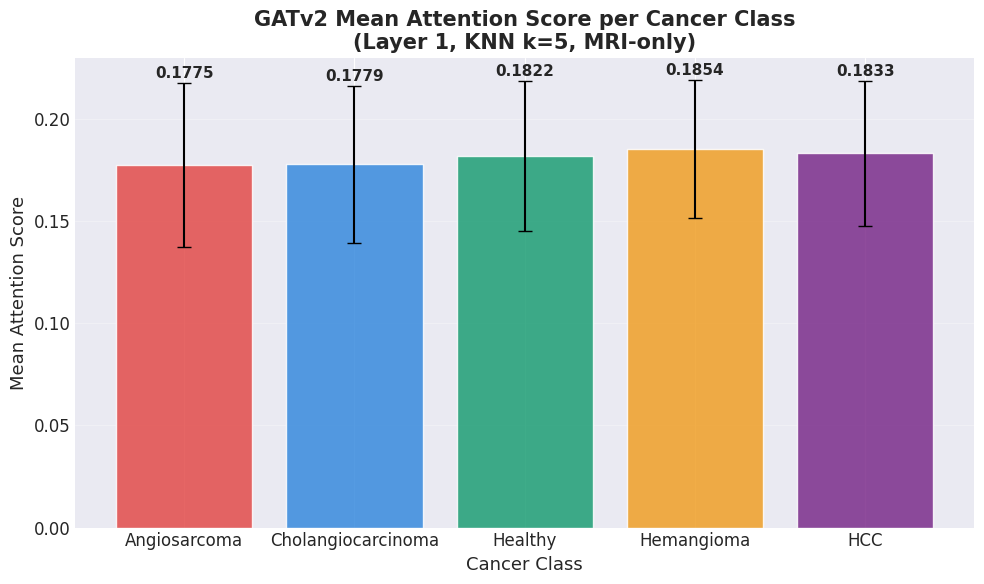

✅ Saved: Figure_Attention_Per_Class.png

Computing t-SNE for attention visualization...


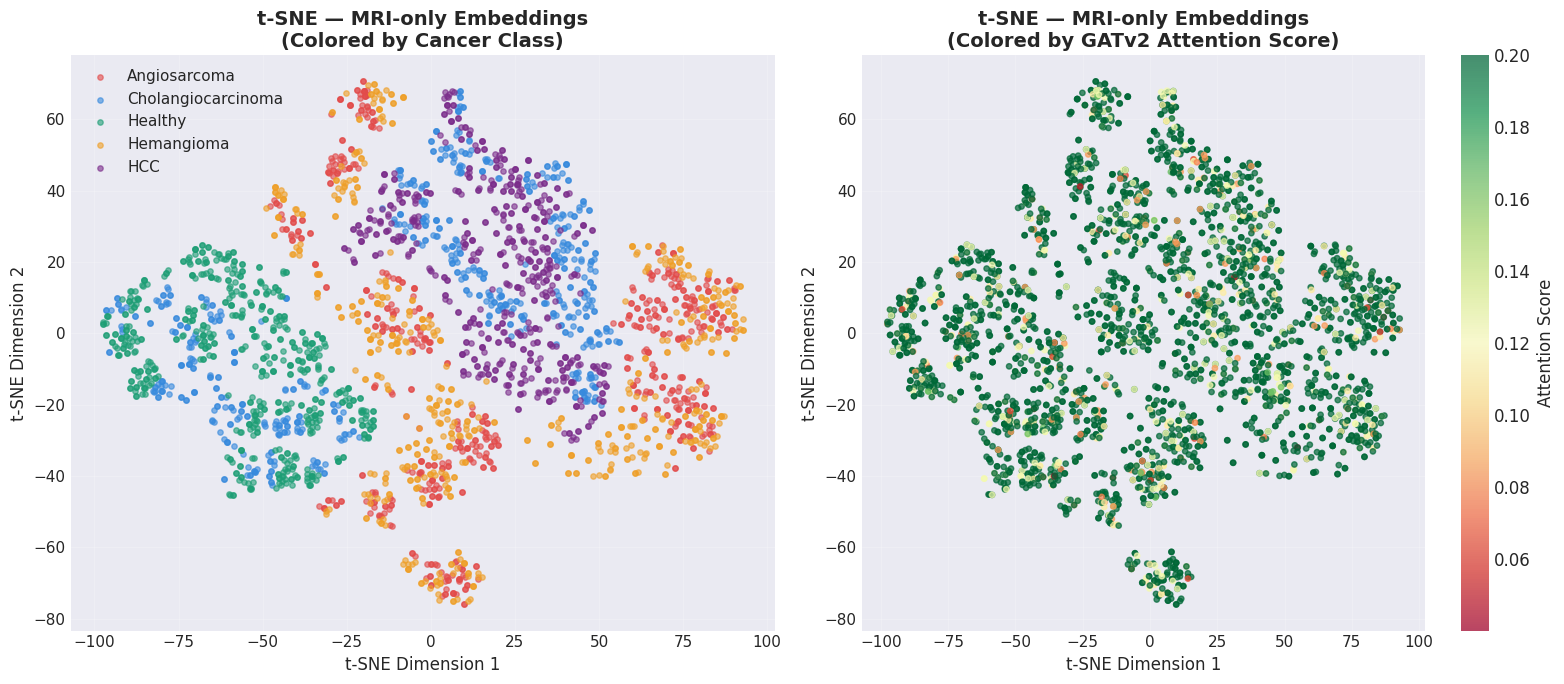

✅ Saved: Figure_Attention_tSNE.png

✅ GATv2 Attention Heatmaps complete!


In [11]:
# CELL 17: GATv2 Attention Heatmaps
# ============================================================

print("=" * 50)
print("🔍 GATv2 ATTENTION HEATMAPS")
print("=" * 50)

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['font.size']   = 12

from torch_geometric.nn import GATv2Conv
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data

# ── Load best model ───────────────────────────
class GATv2Classifier(nn.Module):
    def __init__(self, in_channels, hidden_channels,
                 out_channels, heads=4, dropout=0.4):
        super().__init__()
        self.dropout = dropout
        self.conv1   = GATv2Conv(in_channels, hidden_channels,
                                 heads=heads, dropout=dropout)
        self.conv2   = GATv2Conv(hidden_channels * heads, hidden_channels,
                                 heads=heads, dropout=dropout)
        self.conv3   = GATv2Conv(hidden_channels * heads, out_channels,
                                 heads=1, concat=False, dropout=dropout)
        self.bn1 = nn.BatchNorm1d(hidden_channels * heads)
        self.bn2 = nn.BatchNorm1d(hidden_channels * heads)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv3(x, edge_index)
        return x

    def get_attention(self, x, edge_index):
        """Get attention weights from layer 1"""
        with torch.no_grad():
            _, attn1 = self.conv1(x, edge_index,
                                  return_attention_weights=True)
        return attn1

# ── Load graph and model ──────────────────────
graph = torch.load(f'{EMBEDDINGS_PATH}/graph_mri_only_k5.pt',
                   map_location='cpu', weights_only=False)

model = GATv2Classifier(
    in_channels     = graph.num_node_features,
    hidden_channels = 256,
    out_channels    = 5,
    heads           = 4,
    dropout         = 0.4
)
model.load_state_dict(
    torch.load(f'{MODELS_PATH}/gat_mri_only_knn_k5_best.pth',
               map_location='cpu', weights_only=True)
)
model.eval()
print(f"✅ Model loaded")

# ── Get attention weights ─────────────────────
edge_index_cpu = graph.edge_index.cpu()
x_cpu          = graph.x.cpu()
y_cpu          = graph.y.cpu().numpy()

attn_edge_index, attn_weights = model.get_attention(
    x_cpu, edge_index_cpu
)
# Average across 4 heads
attn_weights_mean = attn_weights.mean(dim=1).numpy()
print(f"✅ Attention weights: {attn_weights.shape}")

# ── Per-node attention score ──────────────────
n_nodes        = graph.num_nodes
node_attn      = np.zeros(n_nodes)
node_count     = np.zeros(n_nodes)

edge_idx = attn_edge_index.numpy()
for i in range(edge_idx.shape[1]):
    src = edge_idx[0, i]
    dst = edge_idx[1, i]
    node_attn[dst]  += attn_weights_mean[i]
    node_count[dst] += 1

node_count[node_count == 0] = 1
node_attn_norm = node_attn / node_count

print(f"✅ Node attention scores computed")

# ── Figure 1: Attention score per class ───────
MRI_CLASSES = [
    'Angiosarcoma', 'Cholangiocarcinoma',
    'Healthy', 'Hemangioma', 'HCC'
]
COLORS = ['#E24B4A', '#378ADD', '#1D9E75', '#EF9F27', '#7B2D8B']

fig, ax = plt.subplots(figsize=(10, 6))

class_attn_means = []
class_attn_stds  = []

for cls in range(5):
    mask       = y_cpu == cls
    cls_attn   = node_attn_norm[mask]
    class_attn_means.append(cls_attn.mean())
    class_attn_stds.append(cls_attn.std())

bars = ax.bar(MRI_CLASSES, class_attn_means,
              color=COLORS, alpha=0.85,
              yerr=class_attn_stds, capsize=5,
              edgecolor='white')

ax.set_title('GATv2 Mean Attention Score per Cancer Class\n'
             '(Layer 1, KNN k=5, MRI-only)',
             fontsize=15, fontweight='bold',
             fontfamily='Times New Roman')
ax.set_xlabel('Cancer Class', fontsize=13,
              fontfamily='Times New Roman')
ax.set_ylabel('Mean Attention Score', fontsize=13,
              fontfamily='Times New Roman')
ax.tick_params(labelsize=12)
ax.grid(True, axis='y', alpha=0.3)

for bar, mean, std in zip(bars, class_attn_means, class_attn_stds):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + std + 0.001,
            f'{mean:.4f}',
            ha='center', va='bottom',
            fontsize=11, fontweight='bold',
            fontfamily='Times New Roman')

plt.tight_layout()
save_path = f'{FIGURES_PATH}/Figure_Attention_Per_Class.png'
plt.savefig(save_path, dpi=400, bbox_inches='tight')
plt.show()
print(f"✅ Saved: Figure_Attention_Per_Class.png")

# ── Figure 2: Top attended nodes t-SNE ────────
from sklearn.manifold import TSNE

print("\nComputing t-SNE for attention visualization...")

np.random.seed(42)
sample_idx    = np.random.choice(n_nodes, 3000, replace=False)
X_sample      = x_cpu.numpy()[sample_idx]
y_sample      = y_cpu[sample_idx]
attn_sample   = node_attn_norm[sample_idx]

tsne      = TSNE(n_components=2, random_state=42,
                 perplexity=40, max_iter=1000)
tsne_emb  = tsne.fit_transform(X_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: colored by class
for cls, (cls_name, color) in enumerate(zip(MRI_CLASSES, COLORS)):
    mask = y_sample == cls
    axes[0].scatter(tsne_emb[mask, 0], tsne_emb[mask, 1],
                    c=color, label=cls_name,
                    alpha=0.6, s=15)

axes[0].set_title('t-SNE — MRI-only Embeddings\n(Colored by Cancer Class)',
                  fontsize=14, fontweight='bold',
                  fontfamily='Times New Roman')
axes[0].set_xlabel('t-SNE Dimension 1', fontsize=12,
                   fontfamily='Times New Roman')
axes[0].set_ylabel('t-SNE Dimension 2', fontsize=12,
                   fontfamily='Times New Roman')
axes[0].legend(fontsize=11)
axes[0].tick_params(labelsize=11)
axes[0].grid(True, alpha=0.2)

# Right: colored by attention score
sc = axes[1].scatter(tsne_emb[:, 0], tsne_emb[:, 1],
                     c=attn_sample, cmap='RdYlGn',
                     alpha=0.7, s=15)
plt.colorbar(sc, ax=axes[1], label='Attention Score')
axes[1].set_title('t-SNE — MRI-only Embeddings\n(Colored by GATv2 Attention Score)',
                  fontsize=14, fontweight='bold',
                  fontfamily='Times New Roman')
axes[1].set_xlabel('t-SNE Dimension 1', fontsize=12,
                   fontfamily='Times New Roman')
axes[1].set_ylabel('t-SNE Dimension 2', fontsize=12,
                   fontfamily='Times New Roman')
axes[1].tick_params(labelsize=11)
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
save_path = f'{FIGURES_PATH}/Figure_Attention_tSNE.png'
plt.savefig(save_path, dpi=400, bbox_inches='tight')
plt.show()
print(f"✅ Saved: Figure_Attention_tSNE.png")

print("\n" + "=" * 50)
print("✅ GATv2 Attention Heatmaps complete!")
print("=" * 50)

In [ ]:
# CELL 18: Train — KNN k=3
# ============================================================

results_k3 = train_gat(
    graph_path = f'{EMBEDDINGS_PATH}/graph_k3.pt',
    graph_name = 'knn_k3',
    epochs     = 300,
    lr         = 0.001
)

🚀 TRAINING: knn_k3
✅ Graph loaded: 11992 nodes, 41486 edges
   Train: 8394 | Val: 1799 | Test: 1799
✅ Inductive subgraphs created!
   Train edges: 22874
   Val edges  : 2513
   Test edges : 2501
   Epoch 020 | Loss: 0.2473 | Train Acc: 0.9092 | Val Acc: 0.9983 | Best: 0.9983
   Epoch 040 | Loss: 0.2004 | Train Acc: 0.9158 | Val Acc: 1.0000 | Best: 1.0000
   Epoch 060 | Loss: 0.1909 | Train Acc: 0.9136 | Val Acc: 1.0000 | Best: 1.0000

⚠️  Early stopping at epoch 75

✅ Best Val Acc: 1.0000 at epoch 25

📊 TEST RESULTS — knn_k3:
   Accuracy  : 1.0000
   Macro F1  : 1.0000
   AUC-ROC   : 1.0000
   Precision : 1.0000
   Recall    : 1.0000

                          precision    recall  f1-score   support

            Angiosarcoma       1.00      1.00      1.00       337
      Cholangiocarcinoma       1.00      1.00      1.00       364
                 Healthy       1.00      1.00      1.00       354
              Hemangioma       1.00      1.00      1.00       371
Hepatocellular Carcinoma  

In [ ]:
# CELL 18b: Train — KNN k=5
# ============================================================

results_k5 = train_gat(
    graph_path = f'{EMBEDDINGS_PATH}/graph_k5.pt',
    graph_name = 'knn_k5',
    epochs     = 300,
    lr         = 0.001
)

🚀 TRAINING: knn_k5
✅ Graph loaded: 11992 nodes, 68898 edges
   Train: 8394 | Val: 1799 | Test: 1799
✅ Inductive subgraphs created!
   Train edges: 36472
   Val edges  : 3143
   Test edges : 3095
   Epoch 020 | Loss: 0.1653 | Train Acc: 0.9401 | Val Acc: 0.9794 | Best: 0.9794
   Epoch 040 | Loss: 0.1330 | Train Acc: 0.9477 | Val Acc: 0.9867 | Best: 0.9872
   Epoch 060 | Loss: 0.1191 | Train Acc: 0.9518 | Val Acc: 0.9867 | Best: 0.9878
   Epoch 080 | Loss: 0.1121 | Train Acc: 0.9514 | Val Acc: 0.9883 | Best: 0.9889
   Epoch 100 | Loss: 0.1011 | Train Acc: 0.9582 | Val Acc: 0.9883 | Best: 0.9889
   Epoch 120 | Loss: 0.1031 | Train Acc: 0.9553 | Val Acc: 0.9883 | Best: 0.9889

⚠️  Early stopping at epoch 123

✅ Best Val Acc: 0.9889 at epoch 73

📊 TEST RESULTS — knn_k5:
   Accuracy  : 0.9928
   Macro F1  : 0.9928
   AUC-ROC   : 0.9998
   Precision : 0.9928
   Recall    : 0.9927

                          precision    recall  f1-score   support

            Angiosarcoma       0.99      0.99 

In [ ]:
# CELL 18c: KNN k=10
results_k10 = train_gat(
    graph_path = f'{EMBEDDINGS_PATH}/graph_k10.pt',
    graph_name = 'knn_k10',
    epochs     = 300,
    lr         = 0.001
)

🚀 TRAINING: knn_k10
✅ Graph loaded: 11992 nodes, 154538 edges
   Train: 8394 | Val: 1799 | Test: 1799
✅ Inductive subgraphs created!
   Train edges: 78068
   Val edges  : 5067
   Test edges : 5053
   Epoch 020 | Loss: 0.2510 | Train Acc: 0.9234 | Val Acc: 0.8961 | Best: 0.8961
   Epoch 040 | Loss: 0.1622 | Train Acc: 0.9466 | Val Acc: 0.9511 | Best: 0.9516
   Epoch 060 | Loss: 0.1250 | Train Acc: 0.9621 | Val Acc: 0.9528 | Best: 0.9539
   Epoch 080 | Loss: 0.0957 | Train Acc: 0.9720 | Val Acc: 0.9522 | Best: 0.9578
   Epoch 100 | Loss: 0.0804 | Train Acc: 0.9749 | Val Acc: 0.9544 | Best: 0.9583
   Epoch 120 | Loss: 0.0687 | Train Acc: 0.9780 | Val Acc: 0.9544 | Best: 0.9605
   Epoch 140 | Loss: 0.0573 | Train Acc: 0.9818 | Val Acc: 0.9583 | Best: 0.9605
   Epoch 160 | Loss: 0.0529 | Train Acc: 0.9817 | Val Acc: 0.9539 | Best: 0.9605

⚠️  Early stopping at epoch 161

✅ Best Val Acc: 0.9605 at epoch 111

📊 TEST RESULTS — knn_k10:
   Accuracy  : 0.9611
   Macro F1  : 0.9606
   AUC-ROC   :

In [ ]:
# CELL 18d: Cosine threshold=0.95
results_cos95 = train_gat(
    graph_path = f'{EMBEDDINGS_PATH}/graph_cosine_095.pt',
    graph_name = 'cosine_095',
    epochs     = 300,
    lr         = 0.001
)

🚀 TRAINING: cosine_095
✅ Graph loaded: 2000 nodes, 40716 edges
   Train: 1400 | Val: 300 | Test: 300
✅ Inductive subgraphs created!
   Train edges: 20306
   Val edges  : 1126
   Test edges : 1280
   Epoch 020 | Loss: 0.6722 | Train Acc: 0.7464 | Val Acc: 0.8567 | Best: 0.8667
   Epoch 040 | Loss: 0.5136 | Train Acc: 0.7971 | Val Acc: 0.8900 | Best: 0.8967
   Epoch 060 | Loss: 0.4606 | Train Acc: 0.8193 | Val Acc: 0.9033 | Best: 0.9033
   Epoch 080 | Loss: 0.4396 | Train Acc: 0.8286 | Val Acc: 0.8500 | Best: 0.9033
   Epoch 100 | Loss: 0.4038 | Train Acc: 0.8336 | Val Acc: 0.8400 | Best: 0.9067
   Epoch 120 | Loss: 0.3889 | Train Acc: 0.8500 | Val Acc: 0.8433 | Best: 0.9067

⚠️  Early stopping at epoch 139

✅ Best Val Acc: 0.9067 at epoch 89

📊 TEST RESULTS — cosine_095:
   Accuracy  : 0.8933
   Macro F1  : 0.8936
   AUC-ROC   : 0.9889
   Precision : 0.8990
   Recall    : 0.8928

                          precision    recall  f1-score   support

            Angiosarcoma       0.90      

In [ ]:
# CELL 18e: Cosine threshold=0.99
results_cos99 = train_gat(
    graph_path = f'{EMBEDDINGS_PATH}/graph_cosine_099.pt',
    graph_name = 'cosine_099',
    epochs     = 300,
    lr         = 0.001
)

🚀 TRAINING: cosine_099
✅ Graph loaded: 2000 nodes, 3064 edges
   Train: 1400 | Val: 300 | Test: 300
✅ Inductive subgraphs created!
   Train edges: 1920
   Val edges  : 320
   Test edges : 326
   Epoch 020 | Loss: 0.7081 | Train Acc: 0.6921 | Val Acc: 0.9767 | Best: 0.9933
   Epoch 040 | Loss: 0.6765 | Train Acc: 0.7057 | Val Acc: 0.9900 | Best: 0.9967
   Epoch 060 | Loss: 0.5862 | Train Acc: 0.7364 | Val Acc: 0.9967 | Best: 0.9967

⚠️  Early stopping at epoch 78

✅ Best Val Acc: 0.9967 at epoch 28

📊 TEST RESULTS — cosine_099:
   Accuracy  : 0.9967
   Macro F1  : 0.9967
   AUC-ROC   : 1.0000
   Precision : 0.9966
   Recall    : 0.9968

                          precision    recall  f1-score   support

            Angiosarcoma       0.98      1.00      0.99        57
      Cholangiocarcinoma       1.00      1.00      1.00        67
                 Healthy       1.00      1.00      1.00        64
              Hemangioma       1.00      0.98      0.99        63
Hepatocellular Carcinoma 

In [ ]:
# CELL 19: CNN Standalone Baseline (Swin Feature Extractor + MLP Head)
# ============================================================

print("=" * 50)
print("🏗️  CNN STANDALONE BASELINE")
print("=" * 50)

class CNNStandaloneClassifier(nn.Module):
    def __init__(self, embedding_dim=1024, num_classes=5, dropout=0.4):
        super(CNNStandaloneClassifier, self).__init__()
        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(x)

# ── Load MRI embeddings ───────────────────────
X_emb = np.load(f'{EMBEDDINGS_PATH}/mri_embeddings.npy')
y_emb = np.load(f'{EMBEDDINGS_PATH}/mri_labels.npy')

print(f"✅ Embeddings loaded: {X_emb.shape}")

# ── Train/Val/Test split ──────────────────────
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_emb, y_emb, test_size=0.30,
    stratify=y_emb, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50,
    stratify=y_temp, random_state=SEED
)

print(f"✅ Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

# ── Convert to tensors ────────────────────────
X_train_t = torch.tensor(X_train, dtype=torch.float).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
X_val_t   = torch.tensor(X_val,   dtype=torch.float).to(device)
y_val_t   = torch.tensor(y_val,   dtype=torch.long).to(device)
X_test_t  = torch.tensor(X_test,  dtype=torch.float).to(device)
y_test_t  = torch.tensor(y_test,  dtype=torch.long).to(device)

# ── DataLoader ────────────────────────────────
from torch.utils.data import TensorDataset

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds   = TensorDataset(X_val_t,   y_val_t)
test_ds  = TensorDataset(X_test_t,  y_test_t)

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=64, shuffle=False)
test_dl  = DataLoader(test_ds,  batch_size=64, shuffle=False)

# ── Model ─────────────────────────────────────
cnn_model = CNNStandaloneClassifier(
    embedding_dim=1024,
    num_classes=5,
    dropout=0.4
).to(device)

# Class weights
class_counts  = np.bincount(y_train)
class_weights = torch.tensor(
    1.0 / class_counts, dtype=torch.float
).to(device)
class_weights = class_weights / class_weights.sum()

optimizer = torch.optim.Adam(
    cnn_model.parameters(), lr=0.001, weight_decay=1e-3
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=15
)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# ── Training ──────────────────────────────────
history_cnn = {
    'train_loss': [], 'train_acc': [],
    'val_loss'  : [], 'val_acc'  : []
}

best_val_acc  = 0
patience_cnt  = 0
PATIENCE      = 30
EPOCHS        = 200

print(f"\n🚀 Training CNN Standalone...")

for epoch in range(1, EPOCHS + 1):
    # Train
    cnn_model.train()
    train_loss, train_correct, total = 0, 0, 0
    for xb, yb in train_dl:
        optimizer.zero_grad()
        out  = cnn_model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item()
        train_correct += (out.argmax(1) == yb).sum().item()
        total         += len(yb)

    train_acc  = train_correct / total
    train_loss = train_loss / len(train_dl)

    # Validate
    cnn_model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for xb, yb in val_dl:
            out       = cnn_model(xb)
            val_loss += criterion(out, yb).item()
            val_correct += (out.argmax(1) == yb).sum().item()
            val_total   += len(yb)

    val_acc  = val_correct / val_total
    val_loss = val_loss / len(val_dl)

    scheduler.step(val_acc)

    history_cnn['train_loss'].append(train_loss)
    history_cnn['train_acc'].append(train_acc)
    history_cnn['val_loss'].append(val_loss)
    history_cnn['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_cnt = 0
        torch.save(cnn_model.state_dict(),
                   f'{MODELS_PATH}/cnn_standalone_best.pth')
    else:
        patience_cnt += 1

    if epoch % 20 == 0:
        print(f"   Epoch {epoch:03d} | "
              f"Loss: {train_loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | "
              f"Val Acc: {val_acc:.4f} | "
              f"Best: {best_val_acc:.4f}")

    if patience_cnt >= PATIENCE:
        print(f"\n⚠️  Early stopping at epoch {epoch}")
        break

# ── Test evaluation ───────────────────────────
cnn_model.load_state_dict(
    torch.load(f'{MODELS_PATH}/cnn_standalone_best.pth',
               weights_only=True)
)
cnn_model.eval()

all_preds, all_trues, all_probs = [], [], []
with torch.no_grad():
    for xb, yb in test_dl:
        out   = cnn_model(xb)
        probs = torch.softmax(out, dim=1).cpu().numpy()
        preds = out.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_trues.extend(yb.cpu().numpy())
        all_probs.extend(probs)

all_preds = np.array(all_preds)
all_trues = np.array(all_trues)
all_probs = np.array(all_probs)

test_acc = accuracy_score(all_trues, all_preds)
prec, rec, f1, _ = precision_recall_fscore_support(
    all_trues, all_preds, average='macro'
)
test_auc = roc_auc_score(
    label_binarize(all_trues, classes=list(range(NUM_CLASSES))),
    all_probs, multi_class='ovr'
)

print(f"\n📊 CNN STANDALONE TEST RESULTS:")
print(f"   Accuracy  : {test_acc:.4f}")
print(f"   Macro F1  : {f1:.4f}")
print(f"   AUC-ROC   : {test_auc:.4f}")
print(f"   Precision : {prec:.4f}")
print(f"   Recall    : {rec:.4f}")
print(f"\n{classification_report(all_trues, all_preds, target_names=MRI_CLASSES)}")

# ── Save ──────────────────────────────────────
import joblib
cnn_results = {
    'history'   : history_cnn,
    'test_acc'  : test_acc,
    'test_f1'   : f1,
    'test_auc'  : test_auc,
    'test_prec' : prec,
    'test_rec'  : rec,
    'test_preds': all_preds,
    'test_trues': all_trues,
    'test_probs': all_probs,
}
joblib.dump(cnn_results, f'{RESULTS_PATH}/cnn_standalone_results.pkl')

print(f"\n✅ Saved: cnn_standalone_results.pkl")
print("=" * 50)
print("✅ CNN Standalone complete!")
print("=" * 50)

🏗️  CNN STANDALONE BASELINE
✅ Embeddings loaded: (11992, 1024)
✅ Train: 8394 | Val: 1799 | Test: 1799

🚀 Training CNN Standalone...
   Epoch 020 | Loss: 0.0052 | Train Acc: 0.9998 | Val Acc: 1.0000 | Best: 1.0000

⚠️  Early stopping at epoch 31

📊 CNN STANDALONE TEST RESULTS:
   Accuracy  : 1.0000
   Macro F1  : 1.0000
   AUC-ROC   : 1.0000
   Precision : 1.0000
   Recall    : 1.0000

                          precision    recall  f1-score   support

            Angiosarcoma       1.00      1.00      1.00       357
      Cholangiocarcinoma       1.00      1.00      1.00       377
                 Healthy       1.00      1.00      1.00       360
              Hemangioma       1.00      1.00      1.00       356
Hepatocellular Carcinoma       1.00      1.00      1.00       349

                accuracy                           1.00      1799
               macro avg       1.00      1.00      1.00      1799
            weighted avg       1.00      1.00      1.00      1799


✅ Saved: cnn_s